In [69]:
from explore_import import  *
import ionbot_preprocess as io
import data_preprocess as dt
import hpp_checker as hpp
import data_preprocess as dt
import pyteomics.auxiliary as aux
import ast
import tpp_preprocess as tpp

import asyncio
import pickle
import time
import os
import itertools 
import time
import re
import ast
from scipy.spatial import distance
from gql import gql, Client
from gql.transport.aiohttp import AIOHTTPTransport
import asyncio

#warnings.simplefilter(action='ignore', category=FutureWarning)

In [70]:
def get_peptide_position(database_peptide, protein, OPfasta):
    count_var=0
    #print(database_peptide, protein, count_var)
    prot_seq=str(OPfasta[protein].seq)
    pos=hpp.get_pep_positions(prot_seq, database_peptide)
    if len(pos)>1: pos=[pos[0]] #take first occurance in protein
    if len(pos)==0: #if didnt find peptide in protein
        # try L->I
        database_peptide = database_peptide.replace('L','I')
        prot_seq=str(OPfasta[protein].seq)
        pos=hpp.get_pep_positions(prot_seq, database_peptide)
        if len(pos)>1: pos=[pos[0]]
        if len(pos)==0:
            count_var+=1;  pos=[np.nan]
    if count_var > 0: print(database_peptide, protein, count_var)
    return pos[0]

In [71]:
# GLOBAL VARS
PIPELINE = 'ionbot_open'
PIPELINE_LW = PIPELINE.lower()

In [72]:
#base directories

root="/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery"
processed_dir=f"{root}/oui-discovery-vv-data/processed/20251015-oui-discovery-ionbot-results"
# get processed files
processed_paths=dt.list_files(processed_dir)
# leave only non-entrapment and open search, only search files
tmp = processed_paths.copy()
for parent, files in processed_paths.items():
    if '-closed' in parent or '-entrap' in parent:
        del tmp[parent]
        continue
    if not any( 'group-walk-output.csv' in f for f in files):
        del tmp[parent]
processed_paths = tmp

# where to save pickles
results_dir = f"{root}/oui-discovery-vv-data/pickles"

20251015-oui-discovery-ionbot-results/
    PXD005833.v0.11.4/
        openprot-x-trembl-filt-global-outerjoin.csv
        PXD005833-opensearch-x-closedsearch-filt-global.csv.gz
        Metadata_PXD005833.v0.11.4-openprot.txt
        ID-rate-df-filt-hybrid.csv
        ID-rate-df-filt-False.csv
        Metadata_PXD005833.v0.11.4-canon.txt
        Metadata_PXD005833.v0.11.4-trembl.txt
        PXD005833-opensearch-x-closedsearch-filt-global-outerjoin.csv.gz
        openprot-x-trembl-filt-global.csv
        ID-rate-df-filt-custom.csv
        ID-rate-df-filt-global.csv
        ID-rate-df-filt-groupwalk.csv
        PXD005833.v0.11.4-canon/
            PXD005833.v0.11.4-canon-combined-features.csv.gz
            combined-results-w-qvalues.csv.gz
            AM15-canon/
                ionbot.first.proteins.csv
                sample-protein-inference-input.pout
                group-walk-output-peptide-vv.csv
                ionbot.features.csv
                ionbot.first.csv
                

In [73]:
OPfasta_file="/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/raw/msfragger_pride_reanalysis/concatenated-fastas/20241102-openprot-database_ionbot_db/concat.fasta"
input_file = open(OPfasta_file)
OPfasta = SeqIO.to_dict(SeqIO.parse(OPfasta_file, "fasta"))

In [6]:
#https://ftp.ensembl.org/pub/release-106/fasta/homo_sapiens/dna/
ENSfasta_file="./../oui-discovery-vv-data/raw/ionbot_openprot/Homo_sapiens.GRCh38.dna.primary_assembly.fa"
input_file = open(ENSfasta_file)
ENSfasta = SeqIO.to_dict(SeqIO.parse(ENSfasta_file, "fasta"))

### Select peptides with isoSAAV

#### Load PSM

In [7]:
psm_filt = []
for parent, files in processed_paths.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if file == 'group-walk-output.csv': #-db
            spectrum_file = '-'.join(parent.split('/')[-1].split('-')[:-1])
            search_database = parent.split('/')[-1].split('-')[-1]
            dataset = parent.split('/')[-2].split('-')[0]
            data = pd.read_csv(os.path.join(parent, file))
            data['spectrum_file'] = spectrum_file
            data['search_database'] = search_database
            data['dataset'] = dataset
            # from Enrico
            # fixes issue with some files being .RAW and other being .raw
            #data.spectrum_file = data.spectrum_file.apply(lambda x: x.split('.')[0])
            # in some mgf files the 'spectrum title' includes the file name, making the spectrum title unique.
            # when the file name is NOT included, spectrum titles are NOT unique, and this can mess up some analysis.
            #data.spectrum_title = data.spectrum_file + ':' + data.spectrum_title.apply(lambda x: x.split(':')[-1])
            psm_filt += [data]
psm_filt = pd.concat(psm_filt)
# NOTE: decoys are retained
psm_filt = psm_filt[(psm_filt['q.value'] < 0.01)&(psm_filt['isCanonical'] != 'Contam')]

# str to list
psm_filt['proteins'] = psm_filt['proteins'].apply(lambda x: x.split(';'))
# indicate proteotypic peptides
psm_filt['isProteotypic'] = psm_filt['proteins'].apply(lambda x: len(x)==1)
# peptide class
psm_filt["peptide_class"]=psm_filt["proteins"].apply(tpp.classify_peptide_tpp)

/tmp/ipykernel_502590/2595102683.py:9: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(parent, file))
/tmp/ipykernel_502590/2595102683.py:9: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(parent, file))


#### Load peptide

In [8]:
pep_filt = []
for parent, files in processed_paths.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if file == 'group-walk-output-peptide-vv.csv' :
            spectrum_file = '-'.join(parent.split('/')[-1].split('-')[:-1])
            search_database = parent.split('/')[-1].split('-')[-1]
            dataset = parent.split('/')[-2].split('-')[0]
            data = pd.read_csv(os.path.join(parent, file))
            data['spectrum_file'] = spectrum_file
            data['search_database'] = search_database
            data['dataset'] = dataset
            pep_filt += [data]
pep_filt = pd.concat(pep_filt)
# NOTE: only target peptides are left
pep_filt = pep_filt[(pep_filt['subset_max_rank'] == True)&(pep_filt['isCanonical'] != 'Contam')]

# str to list
#pep_filt['protein'] = pep_filt['protein'].apply(lambda x: ast.literal_eval(x))
pep_filt['proteins'] = pep_filt['proteins'].apply(lambda x: x.split(';'))
# indicate proteotypic peptides
pep_filt['isProteotypic'] = pep_filt['proteins'].apply(lambda x: len(x)==1)
# peptide class
pep_filt["peptide_class"]=pep_filt["proteins"].apply(tpp.classify_peptide_tpp)

#### Merge PSM and peptide

In [9]:
# Select PSM maching peptide level
psmpep_filt_op = psm_filt[psm_filt['search_database'] == 'openprot']
print('All OP psm', len(psmpep_filt_op))
psmpep_filt_op = psmpep_filt_op[psmpep_filt_op['database_peptide'].isin(pep_filt[pep_filt['search_database'] == 'openprot']['database_peptide'].tolist())]
psmpep_filt_op.reset_index(drop=True,inplace=True)
print('Peptide-level psm', len(psmpep_filt_op))

All OP psm 323529
Peptide-level psm 313941


#### Annotate modifications

In [10]:
from Download_UnimodDB import *

In [11]:
def PTM_string_to_masses_list(ptm_string, unimod):
    if ptm_string=='Unmodified':
        return 'Unmodified'
    # if a peptide has 2 or more possible modified forms, take only 1
    x = ptm_string.split('_or_')[0]
    x = x.split('||')
    x = [_.split('|') for _ in x]
    x = {a:re.split('[][]',b) for a,b in x}
    x = [(int(a),b[3],int(b[1])) for a,b in x.items()]
    x = [(a,b,getPTMmass(c,unimod)) for a,b,c in x]    
    return x
#Modify to parce 9999 not by unimod_id but by code_name
def PTM_string_to_masses_list_9999(ptm_string, unimod, unimod_df):
    if ptm_string=='Unmodified':
        return 'Unmodified'
    # if a peptide has 2 or more possible modified forms, take only 1
    #print(ptm_string)
    x = ptm_string.split('_or_')[0]
    x = x.split('||')
    x = [_.split('|') for _ in x]
    #print(x)
    x = {a:re.split('[][]',b) for a,b in x}
    #print(x)
    x = [(int(a),b[3],int(b[1]) if "9999" not in b[1] else b[2]) for a,b in x.items()]
    x = [(a,b,getPTMmass(c,unimod) if not isinstance(c,str) 
          else float(unimod_df[unimod_df.code_name==c].mono_mass.iloc[0]) if c in unimod_df.code_name.tolist()
         else np.nan) for a,b,c in x]    
    return x

In [12]:
def Download_Unimod_Dict_names():
    unimod = Download_UnimodDB()
    condensed_unimod = {}
    for uni_id,df in unimod.groupby("unimod_id").__iter__():
        condensed_unimod[uni_id] = {}
        condensed_unimod[uni_id]['residues'] = "".join([_ for _ in df.residue if '-' not in _])
        condensed_unimod[uni_id]['mono_mass'] = [_ for _ in set(df.mono_mass)][0]
        condensed_unimod[uni_id]['code_name'] = [_ for _ in set(df.code_name)][0]
        condensed_unimod[uni_id]['full_name'] = [_ for _ in set(df.full_name)][0]
        condensed_unimod[uni_id]['classification'] = [_ for _ in set(df.classification)][0]
        
    return condensed_unimod

In [13]:
# 3-letter to 1-letter amino acid mapping
aa_map = {
    "Ala": "A", "Cys": "C", "Asp": "D", "Glu": "E", "Phe": "F",
    "Gly": "G", "His": "H", "Ile": "I", "Lys": "K", "Leu": "L",
    "Met": "M", "Asn": "N", "Pro": "P", "Gln": "Q", "Arg": "R",
    "Ser": "S", "Thr": "T", "Val": "V", "Trp": "W", "Tyr": "Y",
    "Xle": "L",  # Xle usually refers to Leu/Ile, mapped to Leu ("L") here
    "CamCys": "C", "MetOx": "M"  # Optional: include PTMs if needed
}

# Your list of mutations
mutations = ['His2Asn', 'His2Asp', 'Ala->Ser', 'Ala->Thr', 'Ala->Asp', ...]  # etc.

# Function to extract 1-letter code of the target amino acid
def extract_target_aa(mutation):
    if "->" in mutation:
        target = mutation.split("->")[1]
    elif "2" in mutation:
        target = mutation.split("2")[1]
    else:
        return None  # or raise error if unexpected format

    return aa_map.get(target, "?")  # return '?' if unknown

In [14]:
unimod = Download_Unimod_Dict_names()
unimod_df=pd.DataFrame.from_dict(unimod, orient='index')

In [15]:
#mark substitutions
unimod_df["isSubstitution"]=unimod_df.full_name.apply(lambda x: "substitution" in x)
unimod_df_subs=unimod_df[unimod_df["isSubstitution"]]
#to what residue is change
unimod_df_subs["subs_to_residue"]=unimod_df_subs.code_name.apply(lambda x: extract_target_aa(x))

/tmp/ipykernel_502590/3502357356.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unimod_df_subs["subs_to_residue"]=unimod_df_subs.code_name.apply(lambda x: extract_target_aa(x))


In [16]:
# Remove retention times in parentheses
psmpep_filt_op['modifications_noRT'] = psmpep_filt_op['modifications'].str.replace(r'\([^)]*\)', '', regex=True)

# Convert modifications to mass lists
psmpep_filt_op['modifications_masses'] = psmpep_filt_op['modifications'].map(
    lambda x: PTM_string_to_masses_list_9999(x, unimod, unimod_df)
)

# Extract list of masses and total mass shift in one pass
def extract_mass_info(mods):
    if mods == 'Unmodified':
        return [0], 0
    masses = [mod[2] for mod in mods]
    return masses, np.sum(masses)

mass_info = psmpep_filt_op['modifications_masses'].map(extract_mass_info)
psmpep_filt_op[['masses', 'tot_mass_shift']] = pd.DataFrame(mass_info.tolist(), index=psmpep_filt_op.index)
psmpep_filt_op['tot_mass_shift'] = psmpep_filt_op['tot_mass_shift'].fillna(0)

# Precompute lookups for substitutions and classification
mass_to_residues = unimod_df_subs.groupby('mono_mass')['residues'].apply(set).to_dict()
mass_to_class = unimod_df.groupby('mono_mass')['classification'].apply(list).to_dict()
known_sub_masses = set(mass_to_residues.keys())

def has_substitution(peptide, masses):
    for m in masses:
        if m in known_sub_masses:
            residues = mass_to_residues[m]
            if any(aa in residues for aa in peptide):
                return True
    return False

psmpep_filt_op['isSubstitution'] = [
    has_substitution(peptide, masses)
    for peptide, masses in zip(psmpep_filt_op['database_peptide'], psmpep_filt_op['masses'])
]

psmpep_filt_op['masses_classification'] = psmpep_filt_op['masses'].map(
    lambda masses: [mass_to_class.get(m, []) for m in masses]
)

#### Select isoSAAV

In [17]:
def check_substitution(mod_masses, peptide):
    # Skip "Unmodified"
    if mod_masses == "Unmodified":
        return False
    # For each mass modification
    for _, _, mass in mod_masses:
        residues = mass_to_residues.get(mass)
        if residues:
            peptide = set(peptide)
            # Any AA in peptide match the allowed residues
            if peptide & set(residues):
                return True
    return False

In [18]:
# Precompute a mapping from mono_mass to residue list
mass_to_residues = (
    unimod_df_subs.groupby("mono_mass")["residues"]
    .apply(list)
    .to_dict()
)

In [19]:
#now check that the expected residues of these mass shifts are present in the peptides (without concidering predicted PTM position)
#coution false also can meed Unmodified or non-substitution ptm

psmpep_filt_op["isSubstitution_residue"] = [
    check_substitution(mods, pep)
    for mods, pep in zip(psmpep_filt_op["modifications_masses"], psmpep_filt_op["database_peptide"])
]

In [20]:
#filter out mass shifts of potential substitutuins, where peptide does not contain the expected residue

print('All PSM',len(psmpep_filt_op))
peps_wsub_res=psmpep_filt_op[(psmpep_filt_op.isSubstitution)&(psmpep_filt_op.isSubstitution_residue)].database_peptide.unique()
psmpep_filt_op_isosaaav=psmpep_filt_op[psmpep_filt_op.database_peptide.isin(peps_wsub_res)]
print('PSM of peptides with isoSAAV',len(psmpep_filt_op_isosaaav))

All PSM 313941
PSM of peptides with isoSAAV 196423


/tmp/ipykernel_502590/2434560447.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  a=psmpep_filt_op_isosaaav.groupby("database_peptide").apply(lambda x: Counter(x.isSubstitution_residue)[True]/len(x))


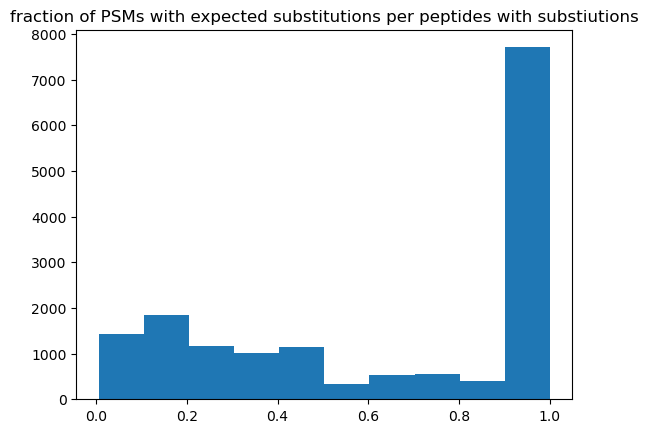

In [21]:
#how many PSMs of these peptides with potential substitutions have potential substitution

a=psmpep_filt_op_isosaaav.groupby("database_peptide").apply(lambda x: Counter(x.isSubstitution_residue)[True]/len(x))
plt.hist(a);
plt.title("fraction of PSMs with expected substitutions per peptides with substiutions");

In [22]:
#with at least one PSM with isoSAAV
(psmpep_filt_op_isosaaav.drop_duplicates("database_peptide").peptide_class.value_counts()
 /
 psmpep_filt_op.drop_duplicates("database_peptide").peptide_class.value_counts())

peptide_class
shared_btw_can_noncan    0.352447
shared_in_Canon          0.322805
unique_to_Canon          0.412838
unique_to_Noncanon       0.787879
shared_in_Noncanon       0.641509
Name: count, dtype: float64

In [23]:
# by protein - some are shared

### Creat all possible peptides with expected substitutions

In [24]:
# Precompute lookup maps
mass_to_subinfo = (
    unimod_df_subs.groupby("mono_mass")[["residues", "subs_to_residue"]]
    .apply(lambda df: list(df.itertuples(index=False)))
    .to_dict()
)
mass_values = set(mass_to_subinfo.keys())

In [25]:
records = []

for database_peptide, group in psmpep_filt_op_isosaaav.groupby("database_peptide"):
    mods = {e for l in group.modifications_masses if l != "Unmodified" for e in l}
    exp_res = [mass_to_subinfo.get(mass, []) for _, aa, mass in mods if mass in mass_values]
    exp_res = [item for sublist in exp_res for item in sublist]

    exp_res = [(r.residues, r.subs_to_residue) for r in exp_res if r.residues in database_peptide]
    mod_res = {aa for aa, _ in exp_res}
    mod_res_poss = [i for i, aa in enumerate(database_peptide) if aa in mod_res]

    exp_peptides = [
        database_peptide[:i] + aa_sub + database_peptide[i + 1:]
        for i in mod_res_poss
        for aa, aa_sub in exp_res if database_peptide[i] == aa
    ]
    saav_info = [
        (i, a, b)
        for exp_pep in exp_peptides
        for i, (a, b) in enumerate(zip(exp_pep, database_peptide))
        if a != b
    ]

    tmp = group.iloc[0][["database_peptide", "peptide_class", "proteins", 'isSubstitution']].to_dict()
    for col in ['dataset', 'spectrum_title', 'scan', 'spectrum_file',
                'observed_retention_time', 'charge', 'modifications_masses']:
        tmp[col] = group[col].tolist()

    tmp.update({
        "fraction_psm_wsub": Counter(group.isSubstitution_residue)[True] / len(group),
        "modifications_set": mods,
        "residues_to_sub": mod_res,
        "pos_to_sub": mod_res_poss,
        "sub_rule": exp_res,
        "peptides_w1sub": exp_peptides,
        "saav_info_pep": saav_info
    })

    records.append(tmp)
    
psmpep_isosaaav = pd.DataFrame(records)

In [26]:
tmp

{'database_peptide': 'YYYVCQYCPAGNWANR',
 'peptide_class': 'shared_in_Canon',
 'proteins': ['P54108-2', 'P54108-3', 'J3KPA1', 'P54108', 'B4E1S8'],
 'isSubstitution': True,
 'dataset': ['PXD005833.v0.11.4', 'PXD005833.v0.11.4'],
 'spectrum_title': ['controllerType=0 controllerNumber=1 scan=24236',
  'controllerType=0 controllerNumber=1 scan=24326'],
 'scan': [24236, 24326],
 'spectrum_file': ['AM9', 'AM12'],
 'observed_retention_time': [3756.04158, 3745.04112],
 'charge': [2, 2],
 'modifications_masses': [[(5, 'C', 57.0215), (8, 'C', 57.0215)],
  [(5, 'C', 57.0215), (8, 'C', 57.0215)]],
 'fraction_psm_wsub': 1.0,
 'modifications_set': {(5, 'C', 57.0215), (8, 'C', 57.0215)},
 'residues_to_sub': {'A', 'G'},
 'pos_to_sub': [9, 10, 13],
 'sub_rule': [('A', 'Q'), ('G', 'N'), ('A', 'Q'), ('G', 'N')],
 'peptides_w1sub': ['YYYVCQYCPQGNWANR',
  'YYYVCQYCPQGNWANR',
  'YYYVCQYCPANNWANR',
  'YYYVCQYCPANNWANR',
  'YYYVCQYCPAGNWQNR',
  'YYYVCQYCPAGNWQNR'],
 'saav_info_pep': [(9, 'Q', 'A'),
  (9, 'Q',

### Explode proteins list for individual assesment of shared peptides

In [27]:
# For shared peptides, expload the proteins list
psmpep_isosaaav['proteins_explode'] = psmpep_isosaaav['proteins']
psmpep_isosaaav = psmpep_isosaaav.explode('proteins_explode')

In [28]:
# get length and position in protein
psmpep_isosaaav["peptide_length"]=psmpep_isosaaav.database_peptide.apply(lambda x: len(x))
# indicate peptide position
psmpep_isosaaav["peptide_position"]='nan'
psmpep_isosaaav['peptide_position'] = psmpep_isosaaav.apply(lambda x: get_peptide_position(x['database_peptide'], x['proteins_explode'], OPfasta), axis=1)

### Identify the genomic coordinates of potential saavs

In [29]:
def check_OPcoords_accession_match(data):
    if data.accession.isna().all():
        #print("no accession")
        return False
    strand=data.strand.tolist()[0]
    if pd.isna(strand):
        #print("no accession matched")
        return False
    return True
    
def get_aa_triplet(protein,posav_aapos,OPcoords):
    data=OPcoords[(OPcoords.accessions==protein)|(OPcoords.accession==protein)]
    #print(data, posav_aapos)
    is_acc=check_OPcoords_accession_match(data)
    if is_acc:
        strand=data.strand.tolist()[0]
        if strand==-1:
            try:
                triplet=data.triplets.tolist()[0][posav_aapos-1-1] #-1
            except IndexError:
                print(data, posav_aapos)
                return np.nan
        else:
            try:
                triplet=data.triplets.tolist()[0][posav_aapos-1-1] #
            except IndexError:
                return np.nan
        return triplet

def get_protein_info(protein,OPcoords,givestrand=False, givechr=False, givegene=False):
    data=OPcoords[(OPcoords.accessions==protein)|(OPcoords.accession==protein)]
    is_acc=check_OPcoords_accession_match(data)
    if is_acc:
        strand=data.strand.tolist()[0]
        if givestrand:
            return strand
        if givechr:
            return data.location_chr.tolist()[0]
        if givegene:
            return data.genes.tolist()[0]

In [30]:
def get_protpos_ofaa_inpep(posinpep,peptide_position):
        #adjust indexing from 1 
        #print(peptide_position)
        posinprot=peptide_position[0]+1+posinpep
        return posinprot

In [31]:
#file was created in explore-3-noncanon-hpp.ipynb

OPcoords=pd.read_pickle("./../../../openprot_query/OPcoords_311.pkl")

In [32]:
# Get all relevant accessions from your working dataframe
proteins_needed = set(psmpep_isosaaav["proteins_explode"].unique())

# Filter down to only relevant proteins
OPcoords = OPcoords[
    OPcoords["accession"].isin(proteins_needed) | OPcoords["accessions"].isin(proteins_needed)
].copy()

del proteins_needed

In [34]:
from pandarallel import pandarallel
pandarallel.initialize(progress_bar=True, nb_workers=20)

INFO: Pandarallel will run on 20 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [36]:
def safe_eval(x):
    if x is None or x is np.nan:
        return None
    if isinstance(x, float) and np.isnan(x):
        return None
    if not isinstance(x, str):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        return None

In [63]:
OPcoords.iloc[0]

transcript_translation_id                                           75998600.0
transcript_id                                                       13513781.0
accession                                                          NP_056473.3
protein_seq_id                                                           57231
type                                                                 reference
segments                     [[959214, 959239], [958928, 959080], [957098, ...
strand                                                                    -1.0
location_chr                                                               1.0
contig_accession                                                           1.0
location_start                                                        944693.0
location_end                                                          959239.0
aug_start                                                                 17.0
aug_stop                                            

In [37]:
OPcoords['segments'] = OPcoords['segments'].parallel_apply(safe_eval)
OPcoords['cds_segments'] = OPcoords['cds_segments'].parallel_apply(safe_eval)
OPcoords['triplets'] = OPcoords['triplets'].parallel_apply(safe_eval)

In [38]:
#identify protein posisions of saav

psmpep_isosaaav["saav_info_prot"]=psmpep_isosaaav.apply(lambda x: 
                                [(get_protpos_ofaa_inpep(peppos,x["peptide_position"]),subto, tosub) 
                                 for peppos, subto, tosub in x["saav_info_pep"]], axis=1)

In [39]:
# --- Preindex OPcoords by accession and accessions for fast lookup ---
# Build dictionaries for O(1) access instead of filtering the DataFrame every time
opcoords_by_accession = {
    acc: row for acc, row in OPcoords.set_index("accession").iterrows()
    if pd.notna(acc)
}
opcoords_by_accessions = {
    acc: row for acc, row in OPcoords.set_index("accessions").iterrows()
    if pd.notna(acc)
}

In [41]:
# --- Fast lookup helper ---
def fast_lookup(protein):
    if protein in opcoords_by_accession:
        return opcoords_by_accession[protein]
    elif protein in opcoords_by_accessions:
        return opcoords_by_accessions[protein]
    else:
        return None

# --- Vectorized get_aa_triplet ---
def get_triplet(protein, pos, lookup):
    row = fast_lookup(protein)
    if row is None or pd.isna(row.get("strand")):
        return np.nan

    triplets = row["triplets"]
    strand = row["strand"]

    idx = pos - 1
    if not isinstance(triplets, (list, tuple)) or idx < 0 or idx >= len(triplets):
        return np.nan

    return triplets[idx]

In [42]:
from pandarallel import pandarallel
pandarallel.initialize(progress_bar=True, nb_workers=20)

INFO: Pandarallel will run on 20 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [43]:
#identify triplet of each substitution
def compute_triplets_row(row):
    protein = row["proteins_explode"]
    info = row["saav_info_prot"]
    return [(get_triplet(protein, pos, fast_lookup), subto, tosub)
            for pos, subto, tosub in info]

psmpep_isosaaav["saav_info_triplet"] = psmpep_isosaaav.parallel_apply(compute_triplets_row, axis=1)


In [44]:
del opcoords_by_accession, opcoords_by_accessions

In [45]:
# annotate chromosome, strand and gene
#note, OPcoords has genes only of uniprot sequences!

for col, field in {"strand": "strand", "chromosome": "location_chr", "gene": "genes"}.items():
    mapping = pd.concat([
        OPcoords.set_index("accession")[field],
        OPcoords.set_index("accessions")[field]
    ])
    # Make sure index is unique — keep the first occurrence
    mapping = mapping[~mapping.index.duplicated(keep="first")]
    
    psmpep_isosaaav[col] = psmpep_isosaaav["proteins_explode"].map(mapping)

In [12]:
reverse_complement_dna={"A":"T","T":"A","C":"G","G":"C","N":"N"}
aminoacid_table={
    'A': ['GCT', 'GCC', 'GCA', 'GCG'],  # Alanine
    'R': ['CGT', 'CGC', 'CGA', 'CGG', 'AGA', 'AGG'],  # Arginine
    'N': ['AAT', 'AAC'],  # Asparagine
    'D': ['GAT', 'GAC'],  # Aspartic acid
    'C': ['TGT', 'TGC'],  # Cysteine
    'Q': ['CAA', 'CAG'],  # Glutamine
    'E': ['GAA', 'GAG'],  # Glutamic acid
    'G': ['GGT', 'GGC', 'GGA', 'GGG'],  # Glycine
    'H': ['CAT', 'CAC'],  # Histidine
    'I': ['ATT', 'ATC', 'ATA'],  # Isoleucine
    'L': ['TTA', 'TTG', 'CTT', 'CTC', 'CTA', 'CTG'],  # Leucine
    'K': ['AAA', 'AAG'],  # Lysine
    'M': ['ATG'],  # Methionine (Start codon)
    'F': ['TTT', 'TTC'],  # Phenylalanine
    'P': ['CCT', 'CCC', 'CCA', 'CCG'],  # Proline
    'S': ['TCT', 'TCC', 'TCA', 'TCG', 'AGT', 'AGC'],  # Serine
    'T': ['ACT', 'ACC', 'ACA', 'ACG'],  # Threonine
    'W': ['TGG'],  # Tryptophan
    'Y': ['TAT', 'TAC'],  # Tyrosine
    'V': ['GTT', 'GTC', 'GTA', 'GTG'],  # Valine
    '*': ['TAA', 'TAG', 'TGA']  # Stop codons
}

aminoacid_table_rev={codon:aa for aa, codons in aminoacid_table.items() for codon in codons}

def get_codon_fromfasta(poss,chromosome,ENSfasta): #strand
    #print(poss)
    if isinstance(poss,float): return np.nan
    codon=[str(ENSfasta[chromosome].seq)[pos-1] for pos in poss]
    #rev_codon=None
    #if strand==-1:
    #        rev_codon=[reverse_compliment_dna[bp] for bp in codon]
    return codon #rev_codon


In [73]:
OPcoords['location_chr'].unique()

array([1.0, nan, 15.0, 17.0, 6.0, 12.0, 10.0, 2.0, '2', '19', '14', 13.0,
       3.0, '3', '4', 'X', '15', 4.0, 5.0, 7.0, 21.0, '7', '8', 8.0, '9',
       9.0, '10', '12', '11', 11.0, 14.0, '16', 16.0, '17', 18.0, 19.0,
       20.0, '20', '21', '22', 22.0, 'Y', 'MT', '1', '5', '6', '13', '18'],
      dtype=object)

In [76]:
# --- Precompute reference codons ---
def get_codons_from_positions(positions, chromosome, ENSfasta):
    """
    positions: list of 1-based positions (triplet)
    Returns list of codon nucleotides (as strings)
    """
    if positions is None or not isinstance(positions, (list, tuple)):
        return np.nan
    seq = str(ENSfasta[chromosome].seq)
    try:
        return [seq[pos-1] for pos in positions]  # 1-based to 0-based
    except IndexError:
        return np.nan

def process_saav_row(row):
    saavs = row["saav_info_triplet"]
    strand = row["strand"]
    chrom = row["chromosome"]

    if not saavs or not isinstance(saavs[0][0], list):
        return np.nan, np.nan
    chrom = str(int(chrom)) if isinstance(chrom,float) else chrom
    #print(chrom)

    refcod_row = []
    refcod_rev_row = []

    for codon_pos, subto, tosub in saavs:
        ref_codon = get_codons_from_positions(codon_pos, chrom, ENSfasta)
        refcod_row.append((ref_codon, subto, tosub))

        if strand == -1 and isinstance(ref_codon, list):
            rev_codon = [reverse_complement_dna[bp] for bp in ref_codon]
            refcod_rev_row.append((rev_codon, subto, tosub))
        else:
            refcod_rev_row.append((ref_codon, subto, tosub))

    return refcod_row, refcod_rev_row


Process ForkPoolWorker-327:
Process ForkPoolWorker-326:
Traceback (most recent call last):
  File "/home/vvshazia/miniconda3/envs/jupyter-py311/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
Traceback (most recent call last):
  File "/home/vvshazia/miniconda3/envs/jupyter-py311/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/vvshazia/miniconda3/envs/jupyter-py311/lib/python3.11/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/home/vvshazia/miniconda3/envs/jupyter-py311/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/vvshazia/miniconda3/envs/jupyter-py311/lib/python3.11/multiprocessing/queues.py", line 364, in get
    with self._rlock:
  File "/home/vvshazia/miniconda3/envs/jupyter-py311/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)

In [65]:
#psmpep_isosaaav.tail()#['chromosome'].iloc[2]

In [78]:
#get reference codon sequence, caution strand
results = psmpep_isosaaav.parallel_apply(process_saav_row, axis=1)

# Split into two columns
psmpep_isosaaav["saav_info_refcod"] = results.apply(lambda x: x[0])
psmpep_isosaaav["saav_info_refcod_rev"] = results.apply(lambda x: x[1])

In [ ]:
#del results

In [89]:
def check_isexpected_aa_fast(row, i, ENSfasta):
    strand = row["strand"]
    ref_aa = row["saav_info_refcod"][i][2]
    codon_list = (
        row["saav_info_refcod_rev"][i][0] if strand == -1
        else row["saav_info_refcod"][i][0]
    )

    if not isinstance(codon_list, list):
        return np.nan

    codon_str = "".join(codon_list)
    expected_codons = codon_set.get(ref_aa, set())

    if codon_str in expected_codons:
        return True

    # try correction if unexpected
    protein = row["proteins_explode"]
    triplets = triplet_lookup.get(protein)
    if not triplets:
        return False

    prot_pos = row["saav_info_prot"][i][0] - 1
    if not (0 <= prot_pos < len(triplets)):
        return False

    new_triplet = triplets[prot_pos]
    chrom = row["chromosome"]
    chrom = str(int(chrom)) if isinstance(chrom,float) else chrom
    new_codon = get_codon_fromfasta(new_triplet, chrom, ENSfasta)
    if strand == -1:
        new_codon = [reverse_complement_dna[bp] for bp in new_codon]

    new_codon_str = "".join(new_codon)
    return new_codon_str in expected_codons


In [84]:
#check if it encodes an expected aa, if not -try to correct result
#I notice that we need left shift on 1 codon with forward strand
#and to 1 right in reverse

# Pre-build lookups to avoid slow OPcoords filtering
triplet_lookup = {}
for _, row in OPcoords.iterrows():
    if isinstance(row.get("triplets"), list):
        if pd.notna(row.get("accession")):
            triplet_lookup[row["accession"]] = row["triplets"]
        if pd.notna(row.get("accessions")):
            triplet_lookup[row["accessions"]] = row["triplets"]

# Pre-cache amino acid codons
aa_to_codons = aminoacid_table
codon_set = {aa: set(codons) for aa, codons in aa_to_codons.items()}

In [85]:
pandarallel.initialize(progress_bar=True, nb_workers=30)

INFO: Pandarallel will run on 30 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [90]:
def row_check_all(row):
    if not isinstance(row["saav_info_refcod"], list):
        return np.nan
    return [
        check_isexpected_aa_fast(row, i, ENSfasta)
        for i in range(len(row["saav_info_refcod"]))
    ]

psmpep_isosaaav["is_expected_aa"] = psmpep_isosaaav.parallel_apply(row_check_all, axis=1)


In [91]:
del triplet_lookup, aa_to_codons, codon_set

In [92]:
psmpep_isosaaav.to_pickle(f'{results_dir}/{PIPELINE_LW}_psmpep_isosaaav.pkl')

In [93]:
#how many peptides have False is_expected_aa - False - 2% - this concideres same peptides but on diff positions (shared peps)

a=Counter(psmpep_isosaaav.apply(lambda x: all(x["is_expected_aa"]) if isinstance(x["saav_info_refcod"],list) else True, axis=1))
(a[False]/sum(list(a.values())))*100

2.069189993490189

In [94]:
# proteins class with unexpected codon
a=psmpep_isosaaav[~psmpep_isosaaav["is_expected_aa"].isna()]['proteins_explode'].unique()
b=[i.startswith(("IP_","II_")) for i in a]
Counter(b)

Counter({False: 15854, True: 7915})

In [95]:
# proteins class with expected codon
a=psmpep_isosaaav['proteins_explode'].unique()
b=[i.startswith(("IP_","II_")) for i in a]
Counter(b)

Counter({False: 24940, True: 7915})

In [96]:
#how many protein accessions were NOT found in OP
len(psmpep_isosaaav[psmpep_isosaaav["is_expected_aa"].isna()]['proteins_explode'].unique())

9086

In [97]:
#how many protein accessions WERE found in OP
len(psmpep_isosaaav[~psmpep_isosaaav["is_expected_aa"].isna()]['proteins_explode'].unique())

23769

#### Check point

In [74]:
# check point
# read big df back
psmpep_isosaaav = pd.read_pickle(f'{results_dir}/{PIPELINE_LW}_psmpep_isosaaav.pkl')

In [75]:
psmpep_isosaaav.iloc[0]

database_peptide                                      AAAAAAAAAAGAAGGRGSGPGR
peptide_class                                                shared_in_Canon
proteins                                                  [Q86U42, Q86U42-2]
isSubstitution                                                          True
dataset                               [PXD014258.v0.11.4, PXD014258.v0.11.4]
spectrum_title             [controllerType=0 controllerNumber=1 scan=1355...
scan                                                          [13556, 13511]
spectrum_file                                     [Sample-BT474, Sample-MCF]
observed_retention_time                             [1538.77764, 1511.67456]
charge                                                                [2, 2]
modifications_masses       [[(0, N-term, 42.0106), (16, R, 28.0313)], [(0...
fraction_psm_wsub                                                        1.0
modifications_set                   {(16, R, 28.0313), (0, N-term, 42.0106)}

In [76]:
#exclude peptides of proteins for which we dont have genomic coordinares (not found accession in OP database)

psmpep_isosaaav_filt=psmpep_isosaaav[~psmpep_isosaaav["is_expected_aa"].isna()].copy(deep=True)

In [77]:
# how many % left after filtering 

(len(psmpep_isosaaav_filt)/len(psmpep_isosaaav))*100

70.15871539725347

In [78]:
del psmpep_isosaaav

In [ ]:
################################################stop here before certain that positions of aa are correct

In [ ]:
#psmpep_isosaaav_filt.iloc[0]

In [ ]:
#psmpep_isosaaav_filt[(psmpep_isosaaav_filt.strand==-1)&(psmpep_isosaaav_filt.peptide_position.apply(lambda x:x[0]<=3))].iloc[100]#.saav_exp_mut               

#### Mark which codons have 1-nucleotide distance from target aa substitution

In [79]:
def dist_1(refcod, cods):
    """Return codons that differ from refcod by exactly 1 base."""
    refcod_arr = np.array(list(refcod))
    cods_arr = np.array([list(c) for c in cods])
    diffs = (cods_arr != refcod_arr).sum(axis=1)
    return [c for c, d in zip(cods, diffs) if d == 1]


def diff_1_bp(refcod, cod):
    """Return position index (0–2) where codon differs."""
    for i, (a, b) in enumerate(zip(cod, refcod)):
        if a != b:
            return i
    return None


psmpep_isosaaav_filt["saav_1bp_dist"] = np.nan
psmpep_isosaaav_filt["saav_exp_mut"] = np.nan

# Precompute amino acid codon lists to avoid repeated dict lookups
aa_codon_cache = {aa: np.array(cods) for aa, cods in aminoacid_table.items()}

saav_1bp_dist_all = []
saav_exp_mut_all = []

for idx, row in psmpep_isosaaav_filt.iterrows():
    refcode = row.saav_info_refcod if row.strand == 1 else row.saav_info_refcod_rev
    triplet, is_exp = row.saav_info_triplet, row.is_expected_aa

    saav_1bp_dist, saav_exp_mut = [], []

    for trip, ref, expected in zip(triplet, refcode, is_exp):
        # Build mutation summary
        res = ["", "", ""]
        
        if not expected:
            saav_1bp_dist.append(False)
            saav_exp_mut.append(tuple(res))
            continue

        codon = ''.join(ref[0])
        aa_codons = aa_codon_cache.get(ref[1], [])
        diff_codons = dist_1(codon, aa_codons)
        if not diff_codons:
            saav_1bp_dist.append(False)
            saav_exp_mut.append(tuple(res))
            continue

        for cod in diff_codons:
            diff_pos = diff_1_bp(codon, cod)
            if diff_pos is not None:
                res[diff_pos] += cod[diff_pos]
        saav_1bp_dist.append(True)
        saav_exp_mut.append(("".join(res[0]), "".join(res[1]), "".join(res[2])))

    saav_1bp_dist_all.append(saav_1bp_dist)
    saav_exp_mut_all.append(saav_exp_mut)

psmpep_isosaaav_filt["saav_1bp_dist"] = saav_1bp_dist_all
psmpep_isosaaav_filt["saav_exp_mut"] = saav_exp_mut_all

In [80]:
# how may substitutions are feasible within single-nucleotide mutation
psmpep_isosaaav_filt["saav_1bp_dist"].apply(any).value_counts()

saav_1bp_dist
True     61504
False    29026
Name: count, dtype: int64

In [81]:
# leave only substitutions which are feasible within single-nucleotide mutation
psmpep_isosaaav_filt = psmpep_isosaaav_filt.loc[psmpep_isosaaav_filt["saav_1bp_dist"].apply(any)]

### query gnomAD

In [82]:
def get_continuous_intervals(nums):
    nums = sorted(set(nums))  # Ensure sorted and unique
    intervals = []
    
    start = prev = nums[0]
    for num in nums[1:]:
        if num == prev + 1:
            prev = num
        else:
            intervals.append((start, prev))
            start = prev = num
    intervals.append((start, prev))  # Append last interval
    return intervals
def merge_close_intervals(intervals, max_gap=1000):
    intervals.sort() # Sort intervals by start
    merged = [intervals[0]]
    for start, end in intervals[1:]:
        last_start, last_end = merged[-1]
        if start - last_end <= max_gap:
            merged[-1] = (last_start, max(end, last_end))  # Merge the intervals
        else:
            merged.append((start, end)) 
    return merged

In [83]:
#API for gnomAD

async def gnomad_response(query):
    transport = AIOHTTPTransport(url="https://gnomad.broadinstitute.org/api",    headers={
        "Accept": "application/json",
        "Content-Type": "application/json",
                "User-Agent": "python-gql-client"
    },
    )
    client = Client(transport=transport, fetch_schema_from_transport=True,execute_timeout=60,)
    result = await client.execute_async(query)
    return result
    
async  def gnomad_api(**kwargs):
    #https://gnomad.broadinstitute.org/downloads#api    
    #request:
    # Position    # VEP annotation
    # Full allele count, and hemizygote/homozygote allele counts.    # Allele number
    # Allele frequency    # Allele counts and numbers by population    # Filters and flags for exome data
    chromosome = kwargs.get('chromosome', '1')
    genome_start = kwargs.get('genome_start', '1')
    genome_stop = kwargs.get('genome_stop', '1')
    query = gql(
        f'''
        query VariantsInGene {{
        region(chrom: "{chromosome}", start: {genome_start}, stop: {genome_stop}, reference_genome: GRCh38) {{
            variants(dataset: gnomad_r4) {{
              gene_symbol
          		gene_id
              variant_id
              pos
              rsids
              transcript_id
              consequence
              hgvsp
               exome {{     
                ac
                an
                af 
            	flags
              }}
              genome {{     
                ac
                an
                af 
            	flags
              }}
            }}
          }}
        }}
    '''
    )
    #populations {
    #              id
    #              ac
    #              an
    #              ac_hemi
    #              ac_hom
    #            }
    result= await gnomad_response(query)
    return result

def get_varvep(result,vep='missense'):
    a=result['gene']['variants']
    return [ a[i] for i in range(len(a)) if vep in a[i]['consequence'] ]
    
def get_saav(hgvsp,prot_pos,ref_aa,new_aa):
    exp_hgvsp=f"p.{hgvp_map[ref_aa]}{prot_pos}{hgvp_map[new_aa]}"
    return hgvsp==exp_hgvsp

async def check_saavs_bygene(chromosome,gencodon_sts): #gene,vep='missense'
    genome_start,genome_stop=min(gencodon_sts),max(gencodon_sts)
    #get SNPs from gnomAD
    gnomad_result= await gnomad_api(chromosome=chromosome,genome_start=genome_start,genome_stop=genome_stop) #gene_symbol=gene)
    is_saavs={}
    for gencodon_st in gencodon_sts:
        is_saav=[]
        for snp in gnomad_result["region"]['variants']:
            if gencodon_st==snp['pos']: is_saav.append(snp)
        is_saavs[gencodon_st]=is_saav
    return is_saavs

### test multy-query

### stop test multy-query

In [84]:
#correct chromosome
psmpep_isosaaav_filt['chromosome'] = psmpep_isosaaav_filt['chromosome'].apply(lambda x: str(int(x)) if isinstance(x,float) else x)

In [85]:
psmpep_isosaaav_filt['chromosome'].unique()

array(['14', '7', '15', '1', '22', '13', '11', '17', '20', '9', '3', '5',
       '8', '19', '18', '16', '2', '4', '12', '10', '6', 'X', '21', 'Y',
       'MT'], dtype=object)

In [86]:
#creat a map of coordinates, to grep bigger ranges in one query

gnomAD_qgr={}
for chromosome, group in psmpep_isosaaav_filt.groupby("chromosome"):
    all_triplets=group['saav_info_triplet'].tolist()
    all_coordinates=list(set([e for row in all_triplets for l in row for e in l[0]]))
    chrom_intervals=get_continuous_intervals(all_coordinates)
    gnomAD_qgr[chromosome]=chrom_intervals

In [87]:
#estimate, how many queries will be made to gnomAD -> too many

len([1 for k,v in gnomAD_qgr.items() for l in v])

31301

In [88]:
#merge intervals with max gap 10000

gnomAD_qgr_m={}
for chromosome, intervals in gnomAD_qgr.items():
    new_intervals=merge_close_intervals(intervals,10000)
    gnomAD_qgr_m[chromosome]=new_intervals

In [89]:
#estimate, how many queries will be made to gnomAD -  many

len([1 for k,v in gnomAD_qgr_m.items() for l in v])

4325

In [90]:
# Skip query for now, get old dictionary
# reference query later from explor-3-massshift-saav-proteotypic

In [91]:
from datetime import datetime

In [24]:
#query gnomAD, repeat attampts automaticly

# Load previous results if they exist
try:
    #gnomAD_qgr_res = pickle.load(open(f"{results_dir}/gnomAD_qgr_res.pickle", "rb"))
    #gnomAD_qgr_m_res = pickle.load(open(f"{results_dir}/gnomAD_qgr_m_res.pickle", "rb"))
    gnomAD_qgr_m_res = pickle.load(open(f"{results_dir}/gnomAD_qgr_m_res2.pickle", "rb"))
except FileNotFoundError:
    #gnomAD_qgr_res = {chrom: {} for chrom in gnomAD_qgr}
    gnomAD_qgr_m_res = {chrom: {} for chrom in gnomAD_qgr_m}

# Track progress
#progress_path = f"{results_dir}/gnomAD_qgr_progress.pickle"
#progress_path = f"{results_dir}/gnomAD_qgr_m_progress.pickle"
progress_path = f"{results_dir}/gnomAD_qgr_m_progress2.pickle"
if os.path.exists(progress_path):
    completed = pickle.load(open(progress_path, "rb"))
else:
    #completed = {chrom: set() for chrom in gnomAD_qgr}
    completed = {chrom: set() for chrom in gnomAD_qgr_m}

for chromosome, intervals in gnomAD_qgr_m.items():
    chromosome = str(int(chromosome)) if isinstance(chromosome,float) else chromosome
    if chromosome not in gnomAD_qgr_m_res:
        gnomAD_qgr_m_res[chromosome] = {}
    if chromosome not in completed:
        completed[chromosome] = set()
        
    i = 0
    while i < len(intervals):
        if i in completed[chromosome]:
            i += 1
            continue
        interval = intervals[i]
        try:
            now = datetime.now(); formatted_time = now.strftime("%H:%M:%S")
            print(f"Processing: {chromosome}, interval {i} , {formatted_time}")
            time.sleep(6)  # Not to overwhelm the server
            result = await check_saavs_bygene("M" if chromosome=="MT" else chromosome, list(range(interval[0], interval[1] + 1)))
            #gnomAD_qgr_res[chromosome].update(result)
            gnomAD_qgr_m_res[chromosome].update(result)

            # Save result and progress
            #pickle.dump(gnomAD_qgr_res, open(f"{results_dir}/gnomAD_qgr_res.pickle", "wb"))
            #pickle.dump(gnomAD_qgr_m_res, open(f"{results_dir}/gnomAD_qgr_m_res.pickle", "wb"))
            pickle.dump(gnomAD_qgr_m_res, open(f"{results_dir}/gnomAD_qgr_m_res2.pickle", "wb"))
            completed[chromosome].add(i)
            pickle.dump(completed, open(progress_path, "wb"))

            print("Saved")
            i += 1  # Only increment if successful
        except Exception as e:
            print(f"{e} at {chromosome}, interval {i}. Retrying...")
            # Will retry same i
            continue

Processing: 1, interval 0 , 20:04:56
Saved
Processing: 1, interval 1 , 20:05:03
Saved
Processing: 1, interval 2 , 20:05:11
Saved
Processing: 1, interval 3 , 20:05:17
Saved
Processing: 1, interval 4 , 20:05:23
Saved
Processing: 1, interval 5 , 20:05:31
Saved
Processing: 1, interval 6 , 20:05:40
Saved
Processing: 1, interval 7 , 20:05:47
Saved
Processing: 1, interval 8 , 20:06:00
Saved
Processing: 1, interval 9 , 20:06:06
Saved
Processing: 1, interval 10 , 20:06:13
Saved
Processing: 1, interval 11 , 20:06:19
Saved
Processing: 1, interval 12 , 20:06:25
Saved
Processing: 1, interval 13 , 20:06:36
Saved
Processing: 1, interval 14 , 20:06:43
Saved
Processing: 1, interval 15 , 20:06:49
Saved
Processing: 1, interval 16 , 20:07:01
Saved
Processing: 1, interval 17 , 20:07:14
Saved
Processing: 1, interval 18 , 20:07:20
Saved
Processing: 1, interval 19 , 20:07:28
Saved
Processing: 1, interval 20 , 20:07:36
Saved
Processing: 1, interval 21 , 20:07:43
Saved
Processing: 1, interval 22 , 20:07:49
Save

#### run to catche missed intervals

In [98]:
def interval_is_complete(res_dict, chrom, interval):
    start, end = interval
    # If no results for this chromosome → not complete
    if chrom not in res_dict:
        return False
    
    # Check whether all positions exist in the result dict
    for pos in range(start, end + 1):
        if pos not in res_dict[chrom]:
            return False
    
    #all_pos = list(range(start, end + 1))
    #res_pos = list(res_dict[chrom].keys())
    #n_ov = len( set(all_pos) & set(res_pos) )
    #if n_ov != len(all_pos):
    #    print(n_ov)
    #    return False

    ##all_len = end - start ; res_len = len(res_dict[chrom].keys())
    ##if all_len != res_len:
    ##    print(all_len,res_len)
    ##    return False

    return True


In [99]:
for chromosome, intervals in gnomAD_qgr_m.items():

    # ensure chromosome key exists in results and completed structures
    if chromosome not in gnomAD_qgr_m_res:
        gnomAD_qgr_m_res[chromosome] = {}
    if chromosome not in completed:
        completed[chromosome] = set()

    i = 0
    while i < len(intervals):

        interval = intervals[i]

        # check if interval already complete
        if interval_is_complete(gnomAD_qgr_m_res, chromosome, interval):
            completed[chromosome].add(i)
            i += 1
            continue

        # ---- API call section ----
        try:
            now = datetime.now(); formatted_time = now.strftime("%H:%M:%S")
            print(f"Processing: {chromosome}, interval {i} , {formatted_time}")
            time.sleep(6)

            # run API
            result = await check_saavs_bygene(
                "M" if chromosome == "MT" else chromosome,
                list(range(interval[0], interval[1] + 1))
            )

            # update results
            gnomAD_qgr_m_res[chromosome].update(result)

            # save
            pickle.dump(gnomAD_qgr_m_res, open(f"{results_dir}/gnomAD_qgr_m_res2.pickle", "wb"))
            completed[chromosome].add(i)
            pickle.dump(completed, open(progress_path, "wb"))

            print("Saved")
            i += 1

        except Exception as e:
            print(f"{e} at {chromosome}, interval {i}. Retrying...")
            continue


Processing: 16, interval 41 , 13:16:34
Saved
Processing: 16, interval 42 , 13:17:10
Saved
Processing: 16, interval 43 , 13:17:40
Saved
Processing: 16, interval 44 , 13:18:09
Saved
Processing: 16, interval 45 , 13:18:39
Saved
Processing: 16, interval 46 , 13:19:08
Saved
Processing: 16, interval 47 , 13:19:38
Saved
Processing: 16, interval 48 , 13:20:07
Saved
Processing: 16, interval 49 , 13:20:35
Saved
Processing: 16, interval 50 , 13:21:10
Saved
Processing: 16, interval 51 , 13:21:38
Saved
Processing: 16, interval 52 , 13:22:08
Saved
Processing: 16, interval 53 , 13:22:37
Saved
Processing: 16, interval 54 , 13:23:05
Saved
Processing: 16, interval 55 , 13:23:44
Saved
Processing: 16, interval 56 , 13:24:14
Saved
Processing: 16, interval 57 , 13:24:43
Saved
Processing: 16, interval 60 , 13:25:13
Saved
Processing: 16, interval 61 , 13:25:45
Saved
Processing: 16, interval 62 , 13:26:19
Saved
Processing: 16, interval 63 , 13:26:49
Saved
Processing: 16, interval 64 , 13:27:19
Saved
Processing

In [102]:
del completed

#### Check point

In [39]:
#psmpep_isosaaav_filt.iloc[0]

In [100]:
gnomAD_qgr_m_res = pickle.load(open(f"{results_dir}/gnomAD_qgr_m_res2.pickle", "rb"))


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x76523704ff50>


In [101]:
print("expected:", np.sum([abs(interval[0]-interval[1])+1 for chrom,intervals in gnomAD_qgr_m.items() for interval in intervals] ))
print("got:", np.sum([len(vals) for chrom,vals in gnomAD_qgr_m_res.items() ]))

expected: 11941098
got: 11941098


In [103]:
# select only needed positions
gnomAD_qgr_res = {chrom:{} for chrom in gnomAD_qgr.keys() if len(gnomAD_qgr_m_res[chrom].keys())!=0}
for chrom, intervals in gnomAD_qgr.items():
    # due to chromosome naming issue
    if len(gnomAD_qgr_m_res[chrom].keys())==0: continue
    for interval in intervals:
        for pos in range(interval[0],interval[1]+1):
            try:
                gnomAD_qgr_res[chrom][pos] = gnomAD_qgr_m_res[chrom][pos]
            except KeyError:
                print(chrom,pos)

In [104]:
print("expected:", np.sum([abs(interval[0]-interval[1])+1 for chrom,intervals in gnomAD_qgr.items() for interval in intervals] ))
print("got:", np.sum([len(vals) for chrom,vals in gnomAD_qgr_res.items() ]))

expected: 131963
got: 131963


In [105]:
#how many positions are empty 

print("empty positions:", np.sum([1 for chrom,vals in gnomAD_qgr_res.items() for v in vals.values() if len(v)==0])/np.sum([len(vals) for chrom,vals in gnomAD_qgr_res.items() ]))

empty positions: 0.42981744883035394


In [106]:
def parce_variantid(x):
    """i=0 chromosome
    i=1 genomic coordinate
    i=2 reference bp
    i=3 variant bp"""
    return x.split("-")

In [107]:
#how many indels - complicated case

print("n of indels in total:", np.sum([1 for chrom,vals in gnomAD_qgr_res.items() 
                                       for v in vals.values() if len(v)!=0
                                       for var in v if len(parce_variantid(var['variant_id'])[2])>1 or len(parce_variantid(var['variant_id'])[3])>1 ]))

n of indels in total: 6099


In [108]:
#how many indels by position

len(set([k for chrom,vals in gnomAD_qgr_res.items() 
                                       for k,v in vals.items() if len(v)!=0
                                       for var in v if len(parce_variantid(var['variant_id'])[2])>1 or len(parce_variantid(var['variant_id'])[3])>1 ]))

5581

In [39]:
# Make a copy
psmpep_isosaaav_filt_tmp = psmpep_isosaaav_filt.copy(deep=True)

# Pre-index OPcoords for faster lookups
OPcoords_indexed = OPcoords.set_index("accessions").combine_first(OPcoords.set_index("accession"))

In [ ]:
def get_segments(x):
    if isinstance(x["saav_info_triplet"][0][0], list):
        try:
            return OPcoords_indexed.loc[x["proteins_explode"], "segments"]
        except KeyError:
            return np.nan
    else:
        return np.nan

def get_cds_segments(x):
    if isinstance(x["saav_info_triplet"][0][0], list):
        try:
            return OPcoords_indexed.loc[x["proteins_explode"], "cds_segments"]
        except KeyError:
            return np.nan
    else:
        return np.nan

# Parallel apply for both columns
#psmpep_isosaaav_filt_tmp["segments"] = psmpep_isosaaav_filt_tmp.parallel_apply(get_segments, axis=1)
#psmpep_isosaaav_filt_tmp["cds_segments"] = psmpep_isosaaav_filt_tmp.parallel_apply(get_cds_segments, axis=1)

In [46]:
# keep only first occurrence of each protein
OPcoords_indexed = OPcoords_indexed[~OPcoords_indexed.index.duplicated(keep="first")]

In [47]:
# 1. Make a mask for valid rows
mask_valid = (
    psmpep_isosaaav_filt_tmp["saav_info_triplet"]
    .apply(lambda s: isinstance(s, list) and len(s) > 0 and isinstance(s[0][0], list))
)
print('got mask_valid')
# 2. Use vectorized `.map()` lookups instead of per-row apply
segments_map = OPcoords_indexed["segments"].to_dict()
cds_segments_map = OPcoords_indexed["cds_segments"].to_dict()
print('got cds_segments_map')

# 3. Initialize with NaN
psmpep_isosaaav_filt_tmp["segments"] = np.nan
psmpep_isosaaav_filt_tmp["cds_segments"] = np.nan

# 4. Assign values only for valid rows using vectorized map
valid_proteins = psmpep_isosaaav_filt_tmp.loc[mask_valid, "proteins_explode"]
print('got valid_proteins')

psmpep_isosaaav_filt_tmp.loc[mask_valid, "segments"] = valid_proteins.map(segments_map)
psmpep_isosaaav_filt_tmp.loc[mask_valid, "cds_segments"] = valid_proteins.map(cds_segments_map)

del mask_valid, segments_map, cds_segments_map, valid_proteins

got mask_valid
got cds_segments_map
got valid_proteins


/tmp/ipykernel_4151916/933915250.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[list([[23321469, 23321819], [23322180, 23322294], [23322998, 23323065], [23323376, 23323482], [23323964, 23324051], [23324137, 23324288], [23325246, 23325285]])
 list([[23321469, 23321819], [23322180, 23322294], [23322998, 23323065], [23323376, 23323482], [23323964, 23324051], [23324137, 23324298]])
 list([[39951299, 39951646]]) ...
 list([[49744330, 49744366], [49737324, 49737397], [49736390, 49736506], [49735503, 49735590], [49733702, 49733847], [49733194, 49733291], [49731162, 49731250], [49728729, 49728856]])
 list([[49744330, 49744366], [49737324, 49737427], [49736390, 49736506], [49735503, 49735590], [49733702, 49733847], [49733194, 49733291], [49731162, 49731250], [49728729, 49728856]])
 list([[49744330, 49744366], [49737324, 49737451], [49736390, 49736506], [49735503, 49735590], [49733702, 49733847], [49733194,

In [48]:
psmpep_isosaaav_filt_tmp.segments.isna().value_counts()

segments
False    90513
Name: count, dtype: int64

In [55]:
psmpep_isosaaav_filt_tmp.iloc[0]

database_peptide                                      AAAAAAAAAAGAAGGRGSGPGR
peptide_class                                                shared_in_Canon
proteins                                                  [Q86U42, Q86U42-2]
isSubstitution                                                          True
dataset                               [PXD014258.v0.11.4, PXD014258.v0.11.4]
spectrum_title             [controllerType=0 controllerNumber=1 scan=1355...
scan                                                          [13556, 13511]
spectrum_file                                     [Sample-BT474, Sample-MCF]
observed_retention_time                             [1538.77764, 1511.67456]
charge                                                                [2, 2]
modifications_masses       [[(0, N-term, 42.0106), (16, R, 28.0313)], [(0...
fraction_psm_wsub                                                        1.0
modifications_set                   {(0, N-term, 42.0106), (16, R, 28.0313)}

In [50]:
del OPcoords_indexed

In [51]:
psmpep_isosaaav_filt_tmp.to_pickle(f'{results_dir}/psmpep_isosaaav_filt_tmp.pkl')


In [53]:
# --- Optimized helper functions ---

def get_segment_fromfasta(poss, chromosome, ENSfasta):
    """Extract a sequence slice from a FASTA chromosome entry."""
    if isinstance(poss, float) or poss is None:
        return ""
    seq = ENSfasta[chromosome].seq
    return str(seq[poss[0]:poss[1] + 1])

def get_gencds(x, ENSfasta):
    """Reconstruct full CDS sequence from segments."""
    segments = x["segments"]
    if not isinstance(segments, list):
        return np.nan
    
    chrom = x["chromosome"]
    strand = x["strand"]

    seq_parts = []
    for seg in segments:
        seg_seq = get_segment_fromfasta(seg, chrom, ENSfasta)
        # Reverse complement only if strand == -1
        if strand == -1:
            seg_seq = seg_seq[::-1]
        seq_parts.append(seg_seq)
    
    return "".join(seq_parts)

def build_gencds_for_rows(df, ENSfasta):
    """Efficient single-core CDS reconstruction."""
    results = np.full(len(df), np.nan, dtype=object)

    for i, (segments, chrom, strand) in enumerate(
        zip(df["segments"], df["chromosome"], df["strand"])
    ):
        # Skip invalid rows early
        if not isinstance(segments, list):
            continue
        
        seq_parts = []
        seq = ENSfasta[chrom].seq

        for start, end in segments:
            part = str(seq[start:end + 1])
            # reverse for negative strand
            if strand == -1:
                part = part[::-1]
            seq_parts.append(part)
        
        results[i] = "".join(seq_parts)
    
    return results
# --- Apply in parallel ---
#psmpep_isosaaav_filt_tmp["chromosome_cds"] = (
#    psmpep_isosaaav_filt_tmp.parallel_apply(
#        lambda x: get_gencds(x, ENSfasta), axis=1
#    )
#)

mask_valid = psmpep_isosaaav_filt_tmp["segments"].apply(lambda s: isinstance(s, list))
psmpep_isosaaav_filt_tmp.loc[mask_valid, "chromosome_cds"] = build_gencds_for_rows(
    psmpep_isosaaav_filt_tmp.loc[mask_valid, ["segments", "chromosome", "strand"]],
    ENSfasta
)

In [54]:
psmpep_isosaaav_filt_tmp.chromosome_cds.isna().value_counts()

chromosome_cds
False    90513
Name: count, dtype: int64

In [56]:
psmpep_isosaaav_filt_tmp.to_pickle(f'{results_dir}/psmpep_isosaaav_filt_tmp.pkl')


In [57]:
#EXPAND the potential saavss table

psmpep_isosaaav_filt_exp=psmpep_isosaaav_filt_tmp.explode(['peptides_w1sub','saav_info_pep', 'saav_info_prot',
                                   'saav_info_triplet','saav_info_refcod','is_expected_aa'])

In [58]:
#map variants to positions

In [59]:
rows = []

for chrom, vals in gnomAD_qgr_res.items():
    for position, variants in vals.items():
        if not variants:
            continue
        for variant in variants:
            chrom_, pos, ref, alt = parce_variantid(variant["variant_id"])
            rows.append((chrom_, pos, ref, alt))

# Create DataFrame in one go
VCFdf = pd.DataFrame(rows, columns=["CHROM", "POS", "REF", "ALT"])

In [60]:
#group by reference

VCFdf_gr = (
    VCFdf.groupby(["CHROM", "POS", "REF"], as_index=False)
         .agg({"ALT": lambda x: ",".join(pd.unique(x))})
)

# Add constant column efficiently
VCFdf_gr["ID"] = "."

In [61]:
# --- Pre-index VCF for faster lookups ---
# Create a fast dictionary keyed by (CHROM, POS)
# Ensure POS is string for consistent lookup
VCFdf_gr["POS"] = VCFdf_gr["POS"].astype(str)
vcf_lookup = (
    VCFdf_gr.groupby(["CHROM", "POS"])[["REF", "ALT"]]
    .apply(lambda df: list(df.itertuples(index=False, name=None)))
    .to_dict()
)

In [62]:
# --- Define helper function ---
def get_ref_alt(x):
    """Map all variant positions for a row to their REF/ALT tuples."""
    if not isinstance(x["saav_info_triplet"][0], list):
        return np.nan

    chrom = x["chromosome"]
    positions = x["saav_info_triplet"][0]

    result = []
    for pos in positions:
        refalt = vcf_lookup.get((chrom, str(pos)), [])
        result.append(refalt)
    return result

# --- Apply in parallel ---
#psmpep_isosaaav_filt_exp["REF_ALT"] = (
#    psmpep_isosaaav_filt_exp.parallel_apply(get_ref_alt, axis=1)
#)

def map_ref_alt(df, vcf_lookup):
    """
    Efficiently map variant REF/ALT values from vcf_lookup to each row in df.
    Avoids pandas apply overhead.
    """
    results = np.empty(len(df), dtype=object)
    for i, (chrom, saav_triplet) in enumerate(zip(df["chromosome"], df["saav_info_triplet"])):
        # Skip invalid or non-list entries early
        if not isinstance(saav_triplet[0], list):
            results[i] = np.nan
            continue

        positions = saav_triplet[0]
        refalt_list = [vcf_lookup.get((chrom, str(pos)), []) for pos in positions]
        results[i] = refalt_list

    return results

# --- Apply efficiently ---
psmpep_isosaaav_filt_exp["REF_ALT"] = map_ref_alt(psmpep_isosaaav_filt_exp, vcf_lookup)

In [64]:
psmpep_isosaaav_filt_exp.REF_ALT.isna().value_counts()


REF_ALT
False    478695
Name: count, dtype: int64

In [66]:
#psmpep_isosaaav_filt_exp.iloc[0]

In [68]:
psmpep_isosaaav_filt_exp.to_pickle(f'{results_dir}/psmpep_isosaaav_filt_exp.pkl')


In [ ]:
#expand by position

In [69]:
# Vectorized extraction of triplet
psmpep_isosaaav_filt_exp["triplet"] = [
    x[0] if isinstance(x[0], list) else np.nan 
    for x in psmpep_isosaaav_filt_exp["saav_info_triplet"]
]

# Explode efficiently
psmpep_isosaaav_filt_exp_var = psmpep_isosaaav_filt_exp.explode(["triplet", "REF_ALT"], ignore_index=True)

In [ ]:
#annotate chromosome position to cds position (python-base) 18833849 
#triplets are 1-base, but segments are 0-based; as we need index for cds mutation, so transform triplet coods to 0-based (-1)

In [70]:
# --- Manual cache dictionaries ---
_cds_positions_cache = {}   # cache for computed CDS base positions
_cds_lookup_cache = {}      # cache for {position: index} lookup tables

def get_cdsbp_cached(segments_tuple, strand):
    """Manually cached computation of CDS base positions for a given (segments, strand)."""
    cache_key = (segments_tuple, strand)
    if cache_key in _cds_positions_cache:
        return _cds_positions_cache[cache_key]

    # Compute once if not cached
    if strand == -1:
        positions = [pos for s in segments_tuple for pos in range(s[1], s[0] - 1, -1)]
    else:
        positions = [pos for s in segments_tuple for pos in range(s[0], s[1] + 1)]

    _cds_positions_cache[cache_key] = positions
    return positions


def get_triplet_cds_pos(x):
    saav_triplet = x.get("saav_info_triplet")
    if not saav_triplet or not isinstance(saav_triplet[0], list):
        return np.nan

    try:
        seg_key = tuple(map(tuple, x["segments"]))  # hashable for cache
        strand = x["strand"]
        triplet_pos = x["triplet"] - 1

        # Get CDS base positions (cached)
        positions = get_cdsbp_cached(seg_key, strand)

        # Create or reuse lookup dict for faster index lookup
        lookup_key = (seg_key, strand)
        if lookup_key not in _cds_lookup_cache:
            _cds_lookup_cache[lookup_key] = {p: i for i, p in enumerate(positions)}

        # O(1) lookup instead of positions.index()
        return _cds_lookup_cache[lookup_key].get(triplet_pos, np.nan)

    except Exception:
        return np.nan


# --- Sequential apply (no parallelization) ---
psmpep_isosaaav_filt_exp_var["triplet_cds_pos"] = (
    psmpep_isosaaav_filt_exp_var.apply(get_triplet_cds_pos, axis=1)
)

In [71]:
del _cds_positions_cache , _cds_lookup_cache

In [72]:
psmpep_isosaaav_filt_exp_var.to_pickle(f'{results_dir}/psmpep_isosaaav_filt_exp_var.pkl')


In [73]:
#expload by reference bp group

psmpep_isosaaav_filt_exp_var=psmpep_isosaaav_filt_exp_var.explode(["REF_ALT"])

In [74]:
#expload by alternative variant

psmpep_isosaaav_filt_exp_var["ALT"]=psmpep_isosaaav_filt_exp_var.REF_ALT.apply(lambda x: x[1].split(",")
                                                                              if isinstance(x,tuple) else np.nan)
psmpep_isosaaav_filt_exp_var=psmpep_isosaaav_filt_exp_var.explode(["ALT"])

In [75]:
psmpep_isosaaav_filt_exp_var["REF"]=psmpep_isosaaav_filt_exp_var.REF_ALT.apply(lambda x: x[0]
                                                                              if isinstance(x,tuple) else np.nan)

In [76]:
#how many variants per peptide class

psmpep_isosaaav_filt_exp_var[~psmpep_isosaaav_filt_exp_var.ALT.isna()].peptide_class.value_counts()#.sum()

peptide_class
shared_btw_can_noncan    769020
shared_in_Canon          220644
unique_to_Noncanon        11542
unique_to_Canon           11481
shared_in_Noncanon         1453
Name: count, dtype: int64

In [77]:
psmpep_isosaaav_filt_exp_var[~psmpep_isosaaav_filt_exp_var.ALT.isna()].drop_duplicates(["chromosome","triplet","REF","ALT"]).peptide_class.value_counts()

peptide_class
shared_btw_can_noncan    87305
shared_in_Canon          43240
unique_to_Canon           7242
unique_to_Noncanon        6698
shared_in_Noncanon         627
Name: count, dtype: int64

In [78]:
#is there variant of canon and non-canon that overlap by pos?

psmpep_isosaaav_filt_exp_var[~psmpep_isosaaav_filt_exp_var.ALT.isna()].groupby("triplet").apply(lambda x: "unique_to_Noncanon" in x["peptide_class"].unique()
                                                                                               and "unique_to_Canon" in x["peptide_class"].unique()).value_counts()

/tmp/ipykernel_4151916/3362697340.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  psmpep_isosaaav_filt_exp_var[~psmpep_isosaaav_filt_exp_var.ALT.isna()].groupby("triplet").apply(lambda x: "unique_to_Noncanon" in x["peptide_class"].unique()


False    99355
True         4
Name: count, dtype: int64

In [80]:
# --- Optimized helper ---
def mutate_cds_fast(x):
    """Mutate a CDS sequence at a given position with the ALT base."""
    try:
        if pd.isna(x["ALT"]) or pd.isna(x["triplet_cds_pos"]) or pd.isna(x["chromosome_cds"]):
            return np.nan
        cds_seq = list(x["chromosome_cds"])
        pos = int(x["triplet_cds_pos"])
        alt = str(x["ALT"])[0]  # handle single-nucleotide alt
        cds_seq[pos] = alt
        return "".join(cds_seq)
    except Exception:
        return np.nan

# --- Parallel apply ---
psmpep_isosaaav_filt_exp_var["chromosome_cds_mutated"] = (
    psmpep_isosaaav_filt_exp_var.parallel_apply(mutate_cds_fast, axis=1)
)

Exception ignored in: <built-in method acquire of _thread.lock object at 0x77edb09acb90>
Traceback (most recent call last):
  File "/home/vvshazia/miniconda3/envs/general/lib/python3.13/multiprocessing/popen_fork.py", line 67, in _launch
    self.pid = os.fork()
KeyboardInterrupt: 


In [82]:
psmpep_isosaaav_filt_exp_var["chromosome_cds_mutated"].isna().value_counts()

chromosome_cds_mutated
False    1009241
True      711036
Name: count, dtype: int64

In [84]:
psmpep_isosaaav_filt_exp_var[["ALT","triplet_cds_pos","chromosome_cds","chromosome_cds_mutated"]].isna().value_counts()

ALT    triplet_cds_pos  chromosome_cds  chromosome_cds_mutated
False  False            False           False                     1009241
True   False            False           True                       699875
       True             False           True                         6262
False  True             False           True                         4899
Name: count, dtype: int64

In [81]:
psmpep_isosaaav_filt_exp_var.to_pickle(f'{results_dir}/psmpep_isosaaav_filt_exp_var.pkl')


#### tmp checkpoint

In [5]:
psmpep_isosaaav_filt_exp_var=pd.read_pickle(f'{results_dir}/psmpep_isosaaav_filt_exp_var.pkl')


In [ ]:
#our target are mutations that do not disrupt the ORF.
# so it can be trancation or elongation, but the first aa should be M and the stop codon should be present
# whenever the exon junctions are affected (not first end of 1st exon and not 2ed end of last exon) 
# do not concider this variant in downstream analysis, as we cant say what is a new exon boundary


In [62]:
#mark idels overlapping with exon junction
#ref pos and alt - if last nuc goes beyoond closest exon

In [8]:
def get_cdsbp_cached(segments_tuple, strand):
    """Cached computation of CDS base positions for segments."""
    segments = list(segments_tuple)
    if strand == -1:
        return [pos for s in segments for pos in range(s[1], s[0] - 1, -1)]
    else:
        return [pos for s in segments for pos in range(s[0], s[1] + 1)]

# --- Optimized splice variant check ---
def if_splicevar_fast(x):
    #print(x)
    if pd.isna(x["ALT"]):
        return False
    
    ref = x["REF"]
    alt = x["ALT"]
    if len(ref) == 1 and len(alt) == 1:
        return False  # not an indel
    
    strand = x["strand"]
    segments = x["segments"]
    first_bp = int(x["triplet"]) - 1
    n_exon = len(segments)
    
    indel_len = max(len(ref), len(alt))
    last_bp = first_bp + indel_len - 1
    
    # find exon index (fast linear scan)
    i_exon = next((i for i, (start, end) in enumerate(segments) if start <= first_bp <= end), None)
    if i_exon is None:
        return False  # outside exons entirely
    
    seg_key = tuple(map(tuple, segments))
    cds_positions = get_cdsbp_cached(seg_key, strand)
    
    insertion = len(ref) < len(alt)
    is_splice_candidate = (
        (last_bp not in cds_positions)
        or (first_bp == segments[i_exon][0])
        or (first_bp == segments[i_exon][1])
    )
    
    if not is_splice_candidate:
        return False
    
    # Handle terminal exon cases by strand direction
    if i_exon in (0, n_exon - 1):
        if strand == 1:
            if (
                (insertion and i_exon == 0 and first_bp == segments[i_exon][0]) or
                (insertion and i_exon == n_exon - 1 and first_bp == segments[i_exon][1])
            ):
                return False
        elif strand == -1:
            if (
                (insertion and i_exon == 0 and first_bp == segments[i_exon][1]) or
                (insertion and i_exon == n_exon - 1 and first_bp == segments[i_exon][0])
            ):
                return False
    return True

# --- Parallel apply ---
psmpep_isosaaav_filt_exp_var["isSpliceVar"] = (
    psmpep_isosaaav_filt_exp_var.parallel_apply(if_splicevar_fast, axis=1)
)

In [9]:
psmpep_isosaaav_filt_exp_var.to_pickle(f'{results_dir}/psmpep_isosaaav_filt_exp_var.pkl')


In [10]:
psmpep_isosaaav_filt_exp_var.isSpliceVar.value_counts()#head()

isSpliceVar
False    1716885
True        3392
Name: count, dtype: int64

In [13]:
# Helper function
def rev_complement_cds(x):
    seq = x["chromosome_cds_mutated"]
    strand = x["strand"]
    alt = x["ALT"]
    
    if pd.isna(alt) or strand != -1 or pd.isna(seq):
        return np.nan
    
    # Use list comprehension + dict lookup
    return "".join(reverse_compliment_dna[bp] for bp in seq)

# Parallel apply
psmpep_isosaaav_filt_exp_var["chromosome_cds_mutated_rev"] = (
    psmpep_isosaaav_filt_exp_var.parallel_apply(rev_complement_cds, axis=1)
)

In [14]:
psmpep_isosaaav_filt_exp_var.to_pickle(f'{results_dir}/psmpep_isosaaav_filt_exp_var.pkl')


In [ ]:
#do translation

In [15]:
def get_triplets_fast(cds):
    """Split CDS sequence into codons (triplets)."""
    triplets = [cds[i:i+3] if i+3 <= len(cds) else cds[i:] + "."*(i+3-len(cds)) 
                for i in range(0, len(cds), 3)]
    return triplets

def translate_cds_fast(x):
    if pd.isna(x["ALT"]):
        return np.nan
    # Select correct strand
    cds_seq = x["chromosome_cds_mutated_rev"] if x["strand"] == -1 else x["chromosome_cds_mutated"]
    if pd.isna(cds_seq):
        return np.nan
    codons = get_triplets_fast(cds_seq)
    protein = "".join(aminoacid_table_rev.get(codon, codon) for codon in codons)
    return protein

# --- Parallel apply ---
psmpep_isosaaav_filt_exp_var["protein_mutated"] = (
    psmpep_isosaaav_filt_exp_var.parallel_apply(translate_cds_fast, axis=1)
)

In [16]:
psmpep_isosaaav_filt_exp_var.to_pickle(f'{results_dir}/psmpep_isosaaav_filt_exp_var.pkl')


In [17]:
#mark 
#if protein does not start from M anymore (disrupted start)
#if premature stop codon. If there is an extention of stop codon - we donts know (analysis does not show)

In [23]:
# Mask rows with valid ALT
mask = ~psmpep_isosaaav_filt_exp_var["ALT"].isna()

# Initialize result as False
is_disrupt = np.zeros(len(psmpep_isosaaav_filt_exp_var), dtype=bool)

# Subset strings to compute only on valid rows
proteins = psmpep_isosaaav_filt_exp_var.loc[mask, "protein_mutated"]

# Compute disruptive variants
starts_not_M = proteins.str.startswith("M") == False
internal_stop = proteins.str.contains(r"\*") & proteins.str.endswith("*") == False

# Combine conditions
is_disrupt[mask] = starts_not_M | internal_stop

# Assign back
psmpep_isosaaav_filt_exp_var["isDisrupt"] = is_disrupt

In [24]:
del mask, is_disrupt, proteins, starts_not_M, internal_stop

In [25]:
psmpep_isosaaav_filt_exp_var.to_pickle(f'{results_dir}/psmpep_isosaaav_filt_exp_var.pkl')


In [26]:
psmpep_isosaaav_filt_exp_var.isDisrupt.value_counts()


isDisrupt
False    1588865
True      131412
Name: count, dtype: int64

In [27]:
#we are omiting splice mutations and orf disraption
#how many?

((psmpep_isosaaav_filt_exp_var.isDisrupt==True)|(psmpep_isosaaav_filt_exp_var.isSpliceVar==True)).value_counts()#[['peptides_w1sub',"protein_mutated"]].iloc[-1]   

False    1585898
True      134379
Name: count, dtype: int64

In [ ]:
#find the peptide with possible saav in protein

In [73]:
def cached_pep_positions(protein, peptide):
    return tuple(hpp.get_pep_positions(protein, peptide))

# --- Helper functions ---
def is_tryptic(protein, pos):
    return (protein[pos[0]-1].startswith(("K", "R"))) and (protein[pos[1]+1].startswith(("K", "R")))

def is_nterm(protein, pos, clip_nM):
    if clip_nM:
        return (pos[0] in (0,1)) and protein[pos[1]+1].startswith(("K","R"))
    else:
        return pos[0]==0 and protein[pos[1]+1].startswith(("K","R"))

def find_tryptic_pep_fast(peptide, protein, clip_nM=True):
    positions = cached_pep_positions(protein, peptide)
    if not positions:
        return "*"
    return any(is_tryptic(protein, pos) or is_nterm(protein, pos, clip_nM) for pos in positions)

#test

def find_pep_positions(peptide, protein, clip_nM=True):
    positions = cached_pep_positions(protein, peptide)
    if not positions:
        return "*"
    return positions

# --- Parallel apply on filtered rows ---
mask = (
    (~psmpep_isosaaav_filt_exp_var["protein_mutated"].isna())
    & (
        (~psmpep_isosaaav_filt_exp_var["ALT"].isna())
        & (
            (~psmpep_isosaaav_filt_exp_var["isSpliceVar"])
            | (~psmpep_isosaaav_filt_exp_var["isDisrupt"])
        )
    )
)
mask = mask.reset_index(drop=True)
results = psmpep_isosaaav_filt_exp_var.iloc[mask.values].parallel_apply(
    lambda x: find_tryptic_pep_fast(x['peptides_w1sub'], x["protein_mutated"]), axis=1
)
#positions = psmpep_isosaaav_filt_exp_var.iloc[mask.values].parallel_apply(
#    lambda x: find_pep_positions(x['peptides_w1sub'], x["protein_mutated"]), axis=1
#)

# Initialize full column as False
psmpep_isosaaav_filt_exp_var["isSAAV"] = False
# Assign results only to relevant rows
psmpep_isosaaav_filt_exp_var.loc[mask.values, "isSAAV"] = results

/tmp/ipykernel_15962/90142907.py:50: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['*' '*' '*' ... '*' '*' '*']' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  psmpep_isosaaav_filt_exp_var.loc[mask.values, "isSAAV"] = results


In [137]:
psmpep_isosaaav_filt_exp_var.loc[mask.values].iloc[-1]#.cds_segments  #.segments#.cds_segments                  #[["database_peptide",'peptides_w1sub', "protein_mutated"]].iloc[1]

database_peptide                                               YYYVCQYCPAGNWANR
peptide_class                                                   shared_in_Canon
proteins                           [P54108-2, P54108-3, J3KPA1, P54108, B4E1S8]
isSubstitution                                                             True
dataset                                  [PXD005833.v0.11.4, PXD005833.v0.11.4]
spectrum_title                [controllerType=0 controllerNumber=1 scan=2423...
scan                                                             [24236, 24326]
spectrum_file                                                       [AM9, AM12]
observed_retention_time                                [3756.04158, 3745.04112]
charge                                                                   [2, 2]
modifications_masses          [[(5, C, 57.0215), (8, C, 57.0215)], [(5, C, 5...
fraction_psm_wsub                                                           1.0
modifications_set                       

In [157]:
segments = psmpep_isosaaav_filt_exp_var.loc[mask.values].iloc[-1].segments
nt=[list(range(st, end+1)) for st, end in segments]
a = []
for _ in nt:
    a+=_
k=0
for i in range(int(len(a)/3)+1):
    #print(i,a[k:k+3])
    if 276-209 == i:
        print(a[k:k+3])
    k+=3

[49736426, 49736427, 49736428]


In [125]:
a=list(range(49731162-1, 49731250))[::1]
k=0
for i in range(int(len(a)/3)+1):
    print(i,a[k:k+3])
    k+=3

0 [49731161, 49731162, 49731163]
1 [49731164, 49731165, 49731166]
2 [49731167, 49731168, 49731169]
3 [49731170, 49731171, 49731172]
4 [49731173, 49731174, 49731175]
5 [49731176, 49731177, 49731178]
6 [49731179, 49731180, 49731181]
7 [49731182, 49731183, 49731184]
8 [49731185, 49731186, 49731187]
9 [49731188, 49731189, 49731190]
10 [49731191, 49731192, 49731193]
11 [49731194, 49731195, 49731196]
12 [49731197, 49731198, 49731199]
13 [49731200, 49731201, 49731202]
14 [49731203, 49731204, 49731205]
15 [49731206, 49731207, 49731208]
16 [49731209, 49731210, 49731211]
17 [49731212, 49731213, 49731214]
18 [49731215, 49731216, 49731217]
19 [49731218, 49731219, 49731220]
20 [49731221, 49731222, 49731223]
21 [49731224, 49731225, 49731226]
22 [49731227, 49731228, 49731229]
23 [49731230, 49731231, 49731232]
24 [49731233, 49731234, 49731235]
25 [49731236, 49731237, 49731238]
26 [49731239, 49731240, 49731241]
27 [49731242, 49731243, 49731244]
28 [49731245, 49731246, 49731247]
29 [49731248, 49731249]


In [121]:
len(a)

88

In [98]:
len(str(OPfasta['J3KPA1'].seq))

276

In [103]:
str(OPfasta['J3KPA1'].seq)[-10:]

'ASCNCSNSIY'

In [ ]:
-2 -> -1

In [79]:
def get_pep_positions_test(prot,pep):    
    print([ m for m in re.finditer(pep, prot)])
    return [(m.start(),m.start()+len(pep)-1) for m in re.finditer(pep, prot)]

In [99]:
peptide="YYYVCQYCPAGNWANR"
protein=str(OPfasta['J3KPA1'].seq)
[ m for m in re.finditer(peptide, protein)]

[<re.Match object; span=(195, 211), match='YYYVCQYCPAGNWANR'>]

In [97]:
protein

"ID: J3KPA1\nName: J3KPA1\nDescription: J3KPA1\nNumber of features: 0\nSeq('MKQIIHPAIETTACTNHFNADPCSTGFVFPAMTIFPVIIFIVAGIIPSFPANED...SIY')"

In [80]:
peptide="YYYVCQYCPAGNWQNR"
protein="VAAAAAAAAAAGAAGGRGSGPGRRRHLVPGAGGEAGEGAPGGAGDY"
get_pep_positions_test(protein, peptide)

[]


[]

In [74]:
psmpep_isosaaav_filt_exp_var["isSAAV"].value_counts()

isSAAV
*        1008732
False     711545
Name: count, dtype: int64

In [48]:
psmpep_isosaaav_filt_exp_var["protein_mutated"].isna().value_counts()[False]

np.int64(1009241)

In [53]:
psmpep_isosaaav_filt_exp_var.loc[mask]['protein_mutated'].isna().value_counts()

protein_mutated
False    1009241
True        4899
Name: count, dtype: int64

In [69]:
mask.value_counts()

True     1008816
False     711461
Name: count, dtype: int64

In [70]:
results.value_counts()

False    1008816
Name: count, dtype: int64

In [68]:
len(results), len(mask), len(psmpep_isosaaav_filt_exp_var)

(1008816, 1720277, 1720277)

In [36]:
del mask, results

In [37]:
psmpep_isosaaav_filt_exp_var.to_pickle(f'{results_dir}/psmpep_isosaaav_filt_exp_var.pkl')


In [38]:
#how many SAAVs we have by peptide class

psmpep_isosaaav_filt_exp_var[["peptide_class","isSAAV"]].value_counts()

peptide_class          isSAAV
shared_btw_can_noncan  False     1347244
shared_in_Canon        False      341098
unique_to_Canon        False       16543
unique_to_Noncanon     False       13625
shared_in_Noncanon     False        1767
Name: count, dtype: int64

In [ ]:
#how many variants overlap on peptide class (affect both canon and non-canon)

(psmpep_isosaaav_filt_exp_var[psmpep_isosaaav_filt_exp_var.isSAAV==True].groupby(["chromosome","triplet","REF","ALT"])["peptide_class"].value_counts()>1).value_counts()

In [ ]:
#how many of SAAVs are if group by same peptide? (so different variants leading to potentialy same PSMs)

psmpep_isosaaav_filt_exp_var[psmpep_isosaaav_filt_exp_var.isSAAV].drop_duplicates("database_peptide",keep="first")[["peptide_class","isSAAV"]].value_counts()

In [ ]:
#how many proteins?

psmpep_isosaaav_filt_exp_var[psmpep_isosaaav_filt_exp_var.isSAAV].drop_duplicates("proteins_explode",keep="first")[["peptide_class","isSAAV"]].value_counts()

In [ ]:
psmpep_isosaaav_filt_exp_var[~psmpep_isosaaav_filt_exp_var.isSAAV].drop_duplicates("database_peptide",keep="first")[["peptide_class","isSAAV"]].value_counts()

In [ ]:
#what are the largest groups?

psmpep_isosaaav_filt_exp_var[psmpep_isosaaav_filt_exp_var.isSAAV==True].groupby("database_peptide").apply(lambda x: len(x)).sort_values()

In [ ]:
#are peptides that have most of n of aa that can be substituted, has most SAAV variants

def count_residues(peptide, residues):
    """Count occurrences of each residue in a peptide using str.count."""
    return {aa: peptide.count(aa) for aa in residues}

# Vectorized apply over rows (still per-row, but much faster than Counter)
psmpep_isosaaav_filt_exp_var["residues_to_sub_count"] = [
    count_residues(row["database_peptide"], row["residues_to_sub"])
    for row in psmpep_isosaaav_filt_exp_var.itertuples(index=False)
]

In [ ]:
psmpep_isosaaav_filt_exp_var.to_pickle(f'{results_dir}/psmpep_isosaaav_filt_exp_var.pkl')

#### Check point

In [ ]:
#psmpep_isosaaav_filt_exp_var = pd.read_pickle(f'{results_dir}/psmpep_isosaaav_filt_exp_var.pkl')

In [ ]:
# select saavs overlapping with identified proteotypic peptides with potential saav

VCFdfaf["isSAAV"]=False
VCFdfaf["peptide_class"]=False
VCFdfaf["database_peptide"]=[[]]*len(VCFdfaf)
VCFdfaf["proteins_explode"]=[[]]*len(VCFdfaf)
issaav_vf=comb_clun_isosub_filt_expvar[comb_clun_isosub_filt_expvar.isSAAV==True][["chromosome","triplet","REF","ALT","peptide_class","database_peptide",'peptides_w1sub',"proteins_explode"]]
for i, row in VCFdfaf.iterrows():
    data=issaav_vf[(issaav_vf.chromosome==row["CHROM"])&(issaav_vf.triplet==int(row["POS"]))&(issaav_vf.REF==row["REF"])&(issaav_vf.ALT==row["ALT"])]
    if len(data)>0:
        #print(data.peptide_class.unique().tolist())
        VCFdfaf.loc[i,"isSAAV"]=True
        VCFdfaf.at[i,"peptide_class"]=data.peptide_class.unique().tolist()
        VCFdfaf.at[i,"database_peptide"]=data.database_peptide.unique().tolist()
        VCFdfaf.at[i,"proteins_explode"]=data.proteins_explode.unique().tolist()

In [ ]:
#n of variants

VCFdfaf[(VCFdfaf.isSAAV==True)]["peptide_class"].value_counts()

In [ ]:
# n of peptides 

VCFdfaf[(VCFdfaf.isSAAV==True)].drop_duplicates("database_peptide")["peptide_class"].value_counts()

In [ ]:
#n of proteins

VCFdfaf[(VCFdfaf.isSAAV==True)].drop_duplicates("proteins_explode")["peptide_class"].value_counts()

In [ ]:
VCFdfaf.columns=['chromosome',	'triplet', 'ID',	'REF',	'ALT'	,'AF', 'isSAAV', 'peptide_class',
       'database_peptide', 'proteins_explode']

In [ ]:
VCFdfaf.triplet=VCFdfaf.triplet.astype(int)
issaav_vfaf=issaav_vf.merge(VCFdfaf, on=['chromosome',	'triplet', 'REF', 'ALT'], how="outer")

In [ ]:
# Initialize with appropriate dtypes
issaav_vfaf['peptides_w1sub_unique'] = pd.Series(dtype='bool')
issaav_vfaf['peptides_w1sub_new'] = pd.Series(dtype='bool')
issaav_vfaf['peptides_w1sub_diffprot'] = pd.Series(dtype='bool')
issaav_vfaf['peptides_w1sub_newprot'] = pd.Series(dtype='object')

for i, row in issaav_vfaf[(issaav_vfaf.isSAAV == True) & (issaav_vfaf["AF"] != 0)].iterrows():
    pep = row.peptides_w1sub
    prot = row.proteins_explode_x

    try:
        unique = is_unique.get(pep, False)
        parts = all_peptide_sequences_byprot[pep].split("|")
        diff_prot = len(parts) > 1 and parts[1] != prot
        new = False
        newprot = parts[1] if diff_prot else "NA"

    except (KeyError, IndexError):
        unique = True
        diff_prot = "NA"
        new = True
        newprot = "NA"

    issaav_vfaf.loc[i, ['peptides_w1sub_unique', 'peptides_w1sub_new',
                        'peptides_w1sub_diffprot', 'peptides_w1sub_newprot']] = [unique, new, diff_prot, newprot]

    #print(unique, diff_prot, new)


In [ ]:
issaav_vfaf[(issaav_vfaf.isSAAV==True)].explode("database_peptide_y")[['peptides_w1sub_unique','peptides_w1sub_new','peptides_w1sub_diffprot']] .value_counts()

In [ ]:
issaav_vfaf[(issaav_vfaf.isSAAV==True)].explode("database_peptide_y")[['peptides_w1sub_unique','peptides_w1sub_new','peptides_w1sub_diffprot','peptides_w1sub_newprot',"peptide_class_x"]] .value_counts()#.sum()


In [ ]:
#get the number of PSMs, that support correspondin isoSAAvs in coresponding peptides

#in the original set of PSMs, find correspinding database_peptide and mass shift

## which substitution rule was used

tmp=comb_clun_isosub_filt_expvar[comb_clun_isosub_filt_expvar.peptides_w1sub.isin(
    issaav_vfaf[(issaav_vfaf.isSAAV==True)].peptides_w1sub.tolist())].drop_duplicates(
    ["database_peptide","peptides_w1sub"])[["database_peptide","peptides_w1sub",'modifications_set','sub_rule',]]

#mark which of mass shifts is substitution unimod_df_subs
def which_sub(x):
    tosub, subto = [(tosub,subto) for tosub, subto in zip(x["database_peptide"],x["peptides_w1sub"]) if tosub!=subto][0]
    df=unimod_df_subs[(
        unimod_df_subs.residues==tosub)&(
        unimod_df_subs.subs_to_residue==subto)&(
        unimod_df_subs.mono_mass.isin([mass for _,_,mass in x["modifications_set"]]))]
    return df.mono_mass.unique()[0]
tmp["mass_is_sub"]=tmp.apply(lambda x:  which_sub(x), axis=1)

#ammong peptides with possible isoSAAV, select those with SAAv
a=[[str(array)] if not "[" in str(array) else list(array) for array in issaav_vfaf[(issaav_vfaf.isSAAV==True)].database_peptide_y.tolist()]
a=[e for l in a for e in l]
comb_clun_isosub_true=comb_clun_isosub[comb_clun_isosub.database_peptide.isin(set(a))]

#explode by 
comb_clun_isosub_true=comb_clun_isosub_true.explode(['dataset', 'spectrum_title','scan', 'spectrum_file', 
                                                     'observed_retention_time', 'charge',
                                                       'modifications_masses'])
#mark which have mass shift that leads to expected SAAV
def which_expSAAV(x):
    if x["modifications_masses"]=="Unmodified":
        return False
    masses=[mass for _,_,mass in x["modifications_masses"]]
    exp_masses=tmp[(tmp.database_peptide==x["database_peptide"])].mass_is_sub.tolist()
    return any(mass in exp_masses for mass in masses)
comb_clun_isosub_true["psm_support_saav"]=comb_clun_isosub_true.apply(lambda x: which_expSAAV(x), axis=1)

In [ ]:
#how many PSMs in total

comb_clun_isosub_true.groupby("database_peptide").apply(lambda x: Counter(x["psm_support_saav"])[True]).sum()

In [ ]:
#percent comparing to modified peps

comb_clun_isosub_true.groupby("database_peptide").apply(lambda x: Counter(x["psm_support_saav"])[True]).sum()/len(comb_datasets[comb_datasets.modifications!="Unmodified"])

In [ ]:
#how many PSMs per peptide_class

comb_clun_isosub_true.groupby("peptide_class").apply(lambda x: (Counter(x["psm_support_saav"])[True]))#.sum()


In [ ]:
#percent of PSMs with mass shift that can be explained by SAAV

comb_clun_isosub_true.groupby("peptide_class").apply(lambda x: (Counter(x["psm_support_saav"])[True]))/comb_datasets_protexp[comb_datasets_protexp.modifications!="Unmodified"].peptide_class.value_counts()[["shared_btw_can_noncan","shared_in_Canon"]]

In [ ]:
#how many peptides with isoSAAv are supported by n PSMs

comb_clun_isosub_true.groupby("database_peptide").apply(lambda x: Counter(x["psm_support_saav"])[True]).value_counts()

In [ ]:
#WHAIT, GROUP BY SPECTRUM TITLE -> REAL NUMBER OF psmS WITH SAAV (NOT EXPLOADED BY PROTEIN LIST)
len(comb_clun_isosub_true[comb_clun_isosub_true["psm_support_saav"]].spectrum_title.unique())

In [ ]:
#save summary table
#select psms that support saavs
save_dir="./oui_discovery_subfigures/explor-3-massshift-saav/"
comb_clun_isosub_true[comb_clun_isosub_true.psm_support_saav].drop('isSubstitution',axis=1).to_csv(f"{save_dir}isosaav_saav_psmbyprot_sharedcanonprot.csv",index=False)

In [ ]:
#save saav information
save_dir="./oui_discovery_subfigures/explor-3-massshift-saav/"
#select variants that lead to expected saavs and have non-zero allele frequency
df=issaav_vfaf[(issaav_vfaf.isSAAV==True)]
#select nessesary columns
df=df[['chromosome',	'triplet', 'REF', 'ALT','AF','peptide_class_x','database_peptide_x',	'peptides_w1sub', 'proteins_explode_x','isSAAV',
      'peptides_w1sub_unique',	'peptides_w1sub_new',	'peptides_w1sub_diffprot',	'peptides_w1sub_newprot']]
#rename
df.columns=['chromosome',	'triplet', 'REF', 'ALT','AF','peptide_class','database_peptide',	'peptides_w1sub', 'proteins_explode','isSAAV',
      'peptides_w1sub_unique',	'peptides_w1sub_new',	'peptides_w1sub_diffprot',	'peptides_w1sub_newprot']
df.to_csv(f"{save_dir}isosaav_saav_gnomad_sharedcanonprot.csv",index=False)

#### load old pickle, select variants needed

In [99]:

#gnomAD_qgr_res = pickle.load(open("./../../../junk/gnomAD_qgr_res.pickle", "rb"))